In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv(r"C:\Shambhavi\Finance Project Credit Risk Assessment\Cleaned Data\Cleaned_Credit_Risk_Dataset.csv")

In [3]:
#Find the number of rows and columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32409 entries, 0 to 32408
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32409 non-null  int64  
 1   person_income               32409 non-null  int64  
 2   person_home_ownership       32409 non-null  str    
 3   person_emp_length           32409 non-null  int64  
 4   loan_intent                 32409 non-null  str    
 5   loan_amnt                   32409 non-null  int64  
 6   loan_int_rate               32409 non-null  float64
 7   loan_status                 32409 non-null  int64  
 8   loan_percent_income         32409 non-null  float64
 9   cb_person_default_on_file   32409 non-null  str    
 10  cb_person_cred_hist_length  32409 non-null  int64  
 11  age_group                   32409 non-null  str    
 12  income_slab                 32409 non-null  str    
dtypes: float64(2), int64(6), str(5)
memory usa

In [4]:
#Displaying data types
df.dtypes

person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length               int64
loan_intent                       str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
age_group                         str
income_slab                       str
dtype: object

In [5]:
#Generating summary statistics
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32409.000000,3.240900e+04,32409.000000,32409.000000,32409.000000,32409.000000,32409.000000,32409.000000
mean,27.730754,6.589428e+04,4.761424,9592.486655,11.014512,0.218705,0.170248,5.811194
std,6.210445,5.251787e+04,3.983757,6320.885127,3.083104,0.413374,0.106785,4.057899
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12250.000000,13.110000,0.000000,0.230000,8.000000
max,94.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [7]:
# Selecting only categorical columns and counting their unique values
categorical_cols = df.select_dtypes(include=['object', 'category','str']).columns
df[categorical_cols].nunique()

person_home_ownership        4
loan_intent                  6
cb_person_default_on_file    2
age_group                    4
income_slab                  4
dtype: int64

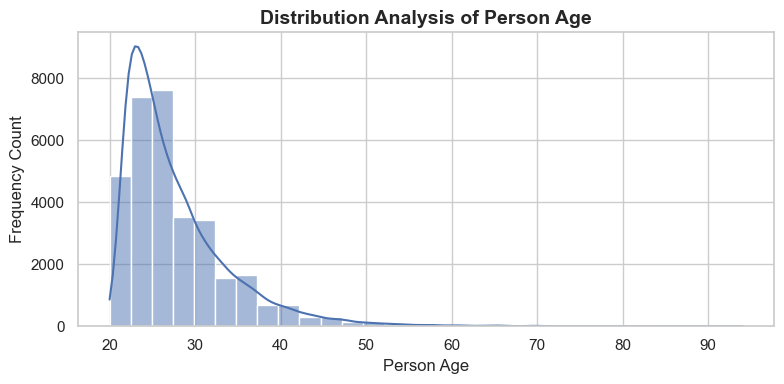

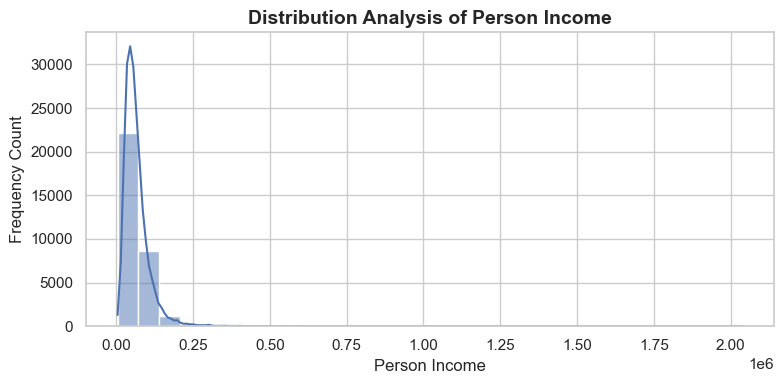

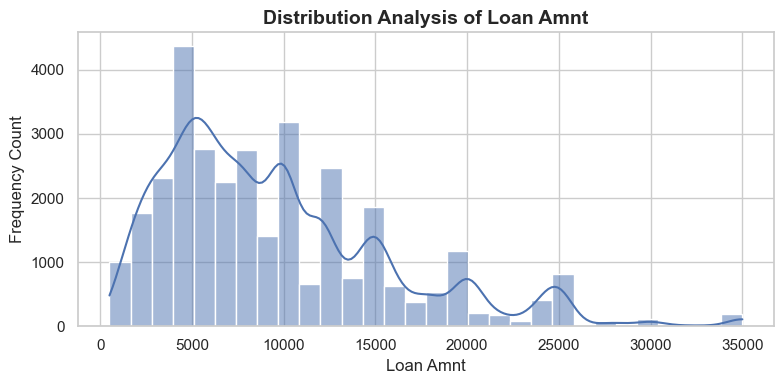

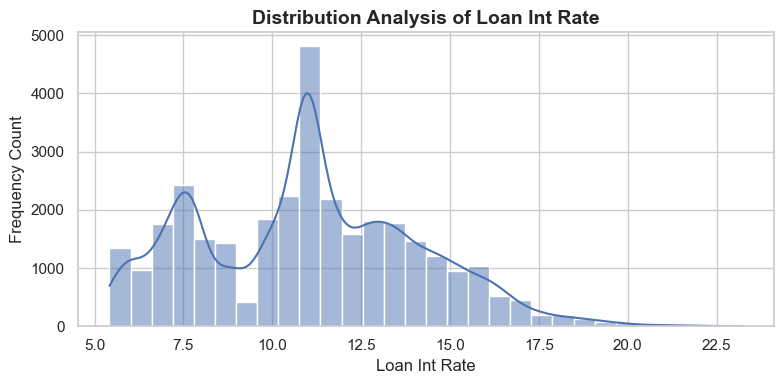

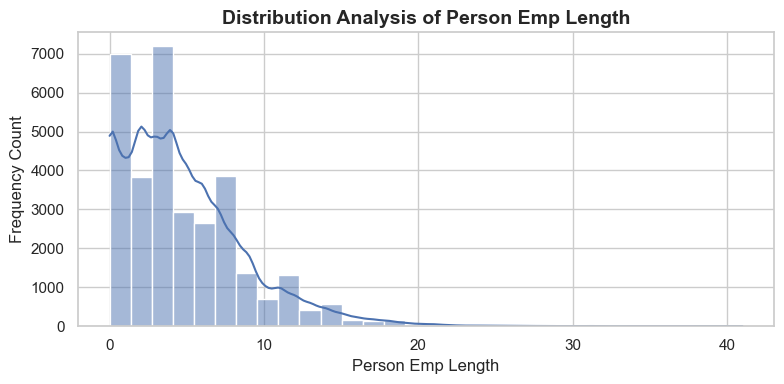

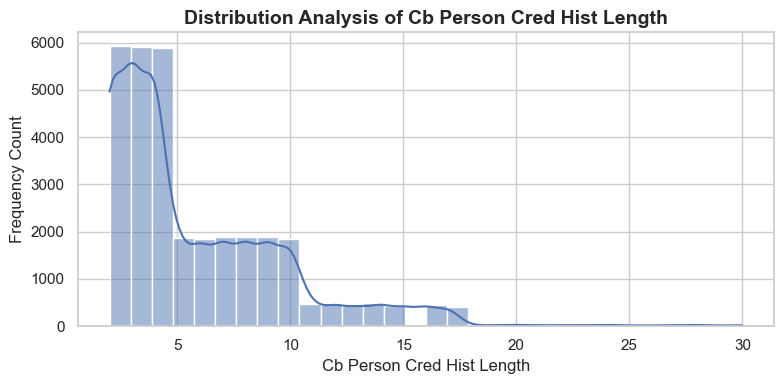

In [12]:
#Performing distribution analysis
dist_cols = [
    'person_age', 
    'person_income', 
    'loan_amnt', 
    'loan_int_rate', 
    'person_emp_length', 
    'cb_person_cred_hist_length'
]

sns.set_theme(style="whitegrid")

for col in dist_cols:
    plt.figure(figsize=(8, 4))
    
    sns.histplot(data=df, x=col, kde=True, bins=30)
    
    plt.title(f"Distribution Analysis of {col.replace('_', ' ').title()}", fontsize=14, fontweight='bold')
    plt.xlabel(col.replace('_', ' ').title(), fontsize=12)
    plt.ylabel("Frequency Count", fontsize=12)
    
    plt.tight_layout()
    plt.show()

In [13]:
# Selecting only categorical columns and counting their unique values
categorical_cols = df.select_dtypes(include=['object', 'category','str']).columns
print(categorical_cols)

Index(['person_home_ownership', 'loan_intent', 'cb_person_default_on_file',
       'age_group', 'income_slab'],
      dtype='str')


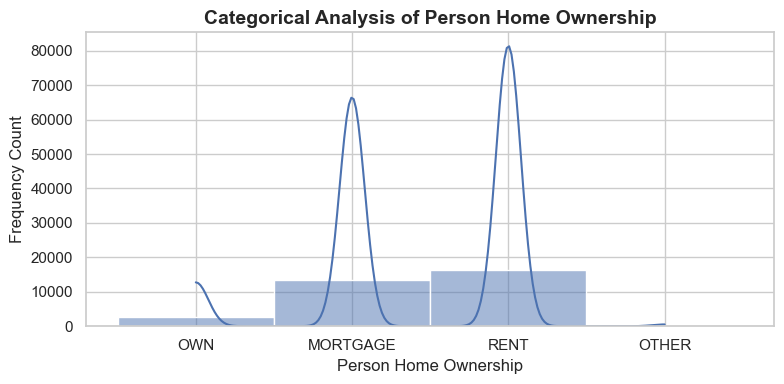

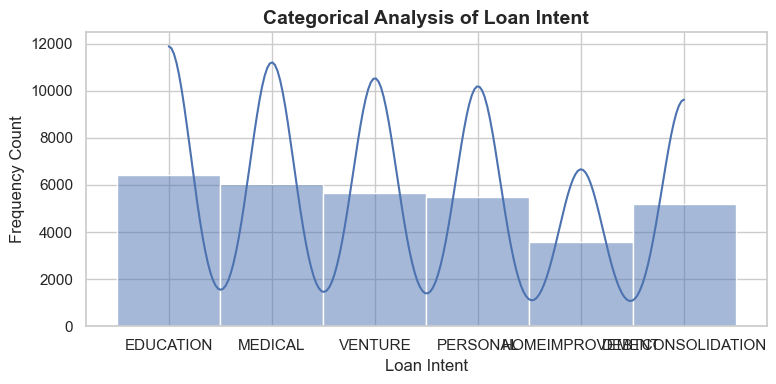

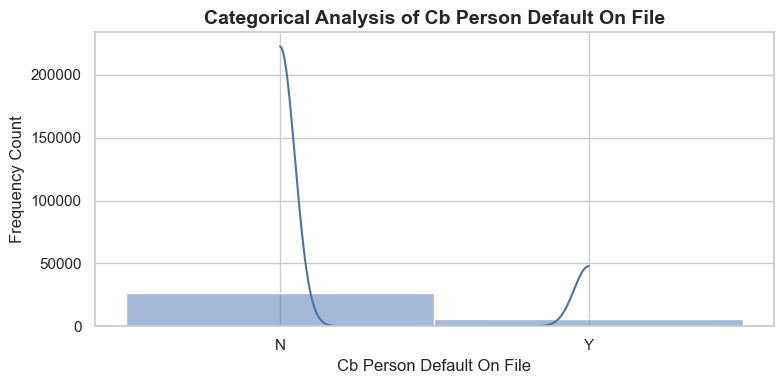

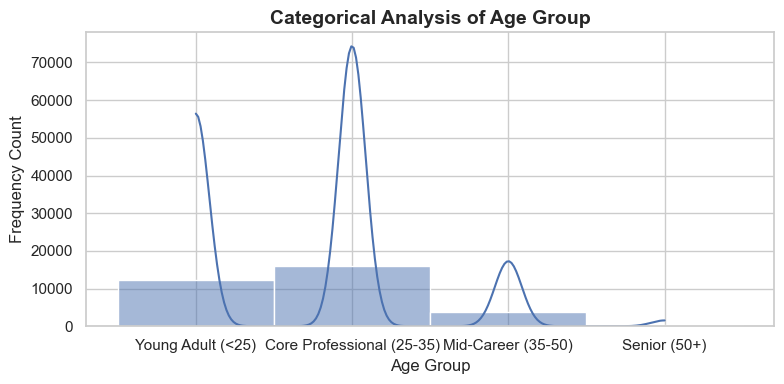

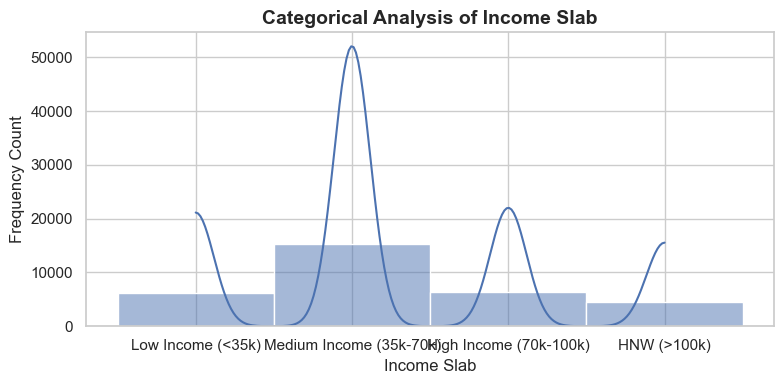

In [14]:
#Performing categorical analysis
cat_cols = ['person_home_ownership', 'loan_intent', 'cb_person_default_on_file',
       'age_group', 'income_slab']

sns.set_theme(style="whitegrid")

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    
    sns.histplot(data=df, x=col, kde=True, bins=30)
    
    plt.title(f"Categorical Analysis of {col.replace('_', ' ').title()}", fontsize=14, fontweight='bold')
    plt.xlabel(col.replace('_', ' ').title(), fontsize=12)
    plt.ylabel("Frequency Count", fontsize=12)
    
    plt.tight_layout()
    plt.show()

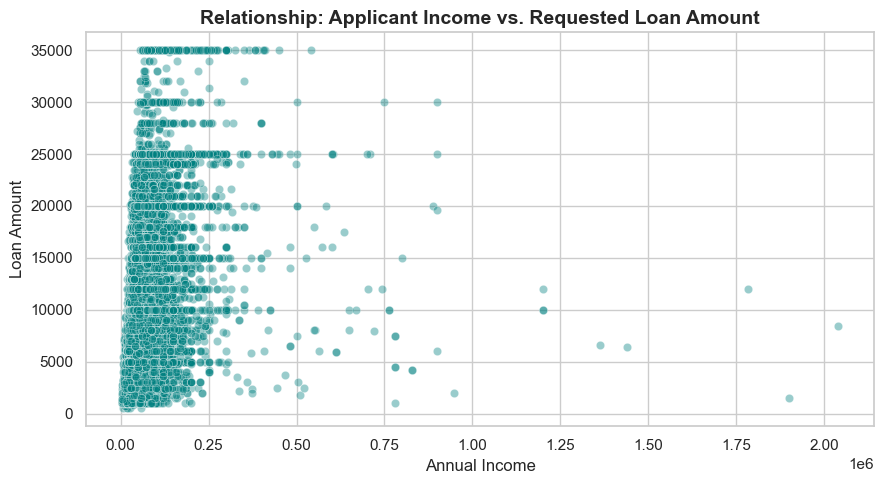

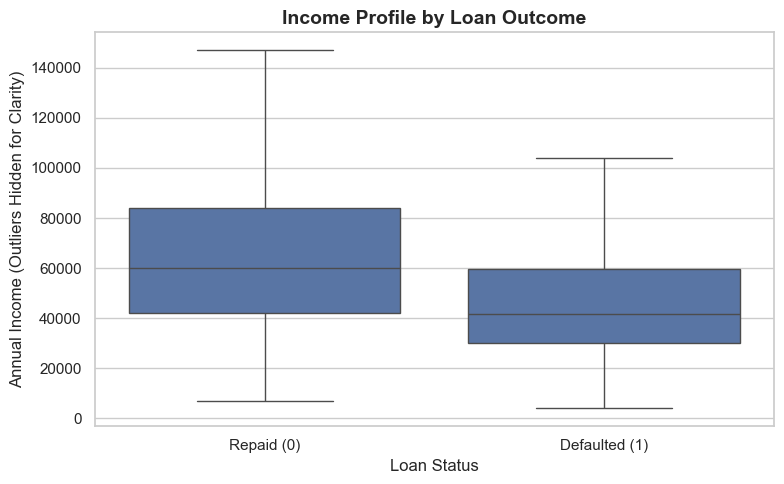

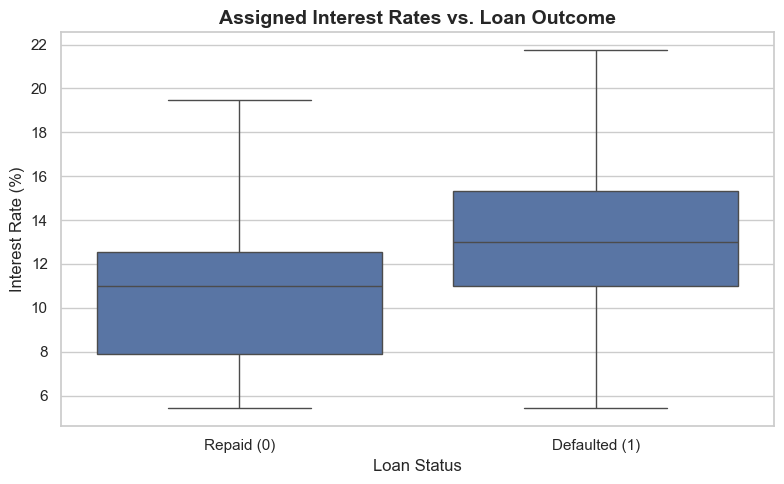

C:\Users\Dr.Shikha\AppData\Local\Temp\ipykernel_22588\508457794.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='loan_status', y='person_emp_length', errorbar=None, palette='muted')


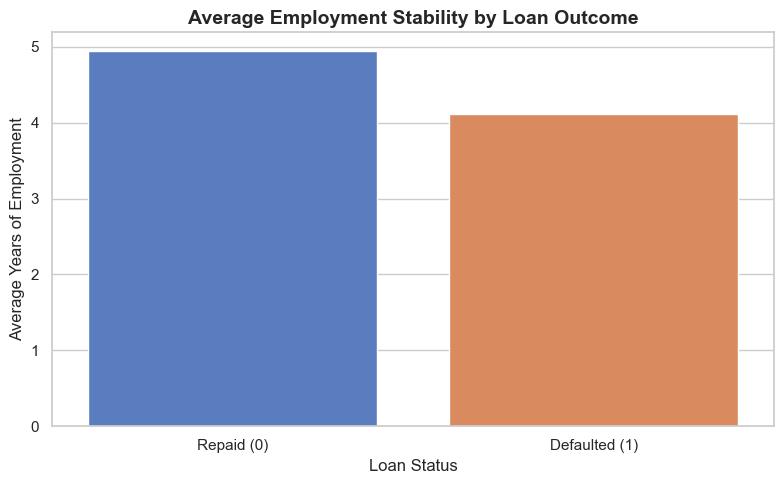

C:\Users\Dr.Shikha\AppData\Local\Temp\ipykernel_22588\508457794.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='loan_status', y='cb_person_cred_hist_length', errorbar=None, palette='pastel')


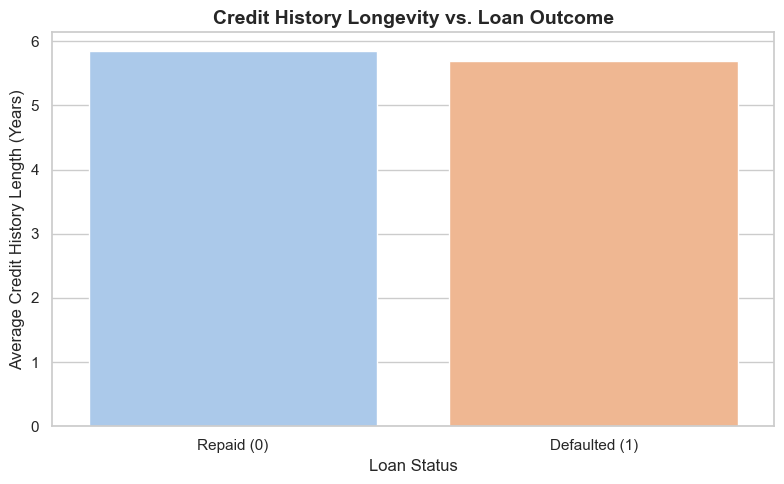

In [15]:
#Performing Relationship Analysis
sns.set_theme(style="whitegrid")

# 1. Income vs. Loan Amount (Continuous vs. Continuous)
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='person_income', y='loan_amnt', alpha=0.4, color='teal')
plt.title("Relationship: Applicant Income vs. Requested Loan Amount", fontsize=14, fontweight='bold')
plt.xlabel("Annual Income", fontsize=12)
plt.ylabel("Loan Amount", fontsize=12)
plt.tight_layout()
plt.show()

# 2. Income vs. Default (Continuous vs. Binary Class)
plt.figure(figsize=(8, 5))
# Using a boxplot to compare the income distribution profiles of both groups
sns.boxplot(data=df, x='loan_status', y='person_income', showfliers=False) 
plt.title("Income Profile by Loan Outcome", fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Repaid (0)', 'Defaulted (1)'])
plt.xlabel("Loan Status", fontsize=12)
plt.ylabel("Annual Income (Outliers Hidden for Clarity)", fontsize=12)
plt.tight_layout()
plt.show()

# 3. Interest Rate vs. Default (Continuous vs. Binary Class)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='loan_status', y='loan_int_rate', showfliers=False)
plt.title("Assigned Interest Rates vs. Loan Outcome", fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Repaid (0)', 'Defaulted (1)'])
plt.xlabel("Loan Status", fontsize=12)
plt.ylabel("Interest Rate (%)", fontsize=12)
plt.tight_layout()
plt.show()

# 4. Employment Length vs. Default (Continuous vs. Binary Class)
plt.figure(figsize=(8, 5))
# Using a bar plot with a confidence interval to track average employment duration
sns.barplot(data=df, x='loan_status', y='person_emp_length', errorbar=None, palette='muted')
plt.title("Average Employment Stability by Loan Outcome", fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Repaid (0)', 'Defaulted (1)'])
plt.xlabel("Loan Status", fontsize=12)
plt.ylabel("Average Years of Employment", fontsize=12)
plt.tight_layout()
plt.show()

# 5. Credit History Length vs. Default (Continuous vs. Binary Class)
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='loan_status', y='cb_person_cred_hist_length', errorbar=None, palette='pastel')
plt.title("Credit History Longevity vs. Loan Outcome", fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Repaid (0)', 'Defaulted (1)'])
plt.xlabel("Loan Status", fontsize=12)
plt.ylabel("Average Credit History Length (Years)", fontsize=12)
plt.tight_layout()
plt.show()

In [31]:
#Identifying all the numerical, boolean and categorical columns in the dataset
all_numeric = df.select_dtypes(include=['number']).columns
all_text = df.select_dtypes(include=['object', 'category', 'str']).columns

numerical_cols = [col for col in all_numeric if df[col].nunique() > 2]
boolean_cols = [col for col in all_numeric if df[col].nunique() <= 2]

categorical_cols = list(all_text)

print("--- DATASET FEATURE PROFILING ---")
print(f"True Continuous Numerical Columns ({len(numerical_cols)}):\n {numerical_cols}\n")
print(f"Boolean / Binary Flag Columns ({len(boolean_cols)}):\n {boolean_cols}\n")
print(f"Categorical Columns ({len(categorical_cols)}):\n {categorical_cols}")


--- DATASET FEATURE PROFILING ---
True Continuous Numerical Columns (7):
 ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

Boolean / Binary Flag Columns (1):
 ['loan_status']

Categorical Columns (5):
 ['person_home_ownership', 'loan_intent', 'cb_person_default_on_file', 'age_group', 'income_slab']


In [32]:
#Identifying Outliers in numerical, boolean and categorical columns

# 1. NUMERICAL OUTLIERS (Using the IQR Method)
print("=== NUMERICAL OUTLIER ANALYSIS (IQR METHOD) ===")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Total outliers found in {col} column: {len(outliers)}")

print("\n" + "="*50 + "\n")

# 2. BOOLEAN COLUMNS (Skipped automatically)
print("=== BOOLEAN COLUMNS ===")
print(f"Skipped {len(boolean_cols)} boolean/binary columns ({boolean_cols}). Binary flags do not contain statistical outliers.\n")
print("="*50 + "\n")


# 3. CATEGORICAL OUTLIERS (Identifying Rare Labels < 1% of dataset)
print("=== CATEGORICAL OUTLIER ANALYSIS (RARE LABELS) ===")
threshold = 0.01 

for col in categorical_cols:
    label_freqs = df[col].value_counts(normalize=True)
    
    rare_labels = label_freqs[label_freqs < threshold].index.tolist()
    
    if rare_labels:
        print(f"Rare category 'outliers' detected in '{col}': {rare_labels}")
        rare_count = df[col].isin(rare_labels).sum()
        print(f"   -> Total rows affected: {rare_count}")
    else:
        print(f"No rare category 'outliers' detected in '{col}' (all categories are well-represented).")



=== NUMERICAL OUTLIER ANALYSIS (IQR METHOD) ===
Total outliers found in person_age column: 1486
Total outliers found in person_income column: 1474
Total outliers found in person_emp_length column: 850
Total outliers found in loan_amnt column: 1678
Total outliers found in loan_int_rate column: 70
Total outliers found in loan_percent_income column: 649
Total outliers found in cb_person_cred_hist_length column: 1138


=== BOOLEAN COLUMNS ===
Skipped 1 boolean/binary columns (['loan_status']). Binary flags do not contain statistical outliers.


=== CATEGORICAL OUTLIER ANALYSIS (RARE LABELS) ===
Rare category 'outliers' detected in 'person_home_ownership': ['OTHER']
   -> Total rows affected: 106
No rare category 'outliers' detected in 'loan_intent' (all categories are well-represented).
No rare category 'outliers' detected in 'cb_person_default_on_file' (all categories are well-represented).
No rare category 'outliers' detected in 'age_group' (all categories are well-represented).
No rare 

In [33]:
#Dealing with outliers in numerical columns
df_clean = df.copy()

print("=== APPLYING IQR CAPPING (WINSORIZATION) ===")

for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    lower_outliers = (df_clean[col] < lower_bound).sum()
    upper_outliers = (df_clean[col] > upper_bound).sum()
    
    if lower_outliers > 0 or upper_outliers > 0:
        print(f"Capping '{col}': {lower_outliers} values below floor, {upper_outliers} values above cap.")
        
        df_clean[col] = np.clip(df_clean[col], lower_bound, upper_bound)
    else:
        print(f"'{col}' requires no capping (0 outliers found).")

print("\nOutlier capping complete! All values are now within statistical boundaries.")

=== APPLYING IQR CAPPING (WINSORIZATION) ===
Capping 'person_age': 0 values below floor, 1486 values above cap.
Capping 'person_income': 0 values below floor, 1474 values above cap.
Capping 'person_emp_length': 0 values below floor, 850 values above cap.
Capping 'loan_amnt': 0 values below floor, 1678 values above cap.
Capping 'loan_int_rate': 0 values below floor, 70 values above cap.
Capping 'loan_percent_income': 0 values below floor, 649 values above cap.
Capping 'cb_person_cred_hist_length': 0 values below floor, 1138 values above cap.

Outlier capping complete! All values are now within statistical boundaries.


In [ ]:
#Exporting the dataset whose outliers are dealt with
df_clean.to_csv('credit_risk_cleaned_eda.csv', index=False)

print("Dataset successfully exported as 'credit_risk_cleaned_eda.csv'!")